In [36]:
import numpy as np
import pandas as pd
import kagglehub
import numpy.linalg as linalg
import matplotlib.pyplot as plt

In [37]:
#Closed Form Linear Regression

def LinRegExact(X,y):
    mat=np.dot(linalg.inv(np.dot(X.transpose(),X)),X.transpose())
    beta=np.dot(mat,y)
    return beta

In [38]:
#Grad desc. Linear Regression Normalised

def LinRegGradDesc(X,y,learningRate=0.01,iterations=500000):
    test=np.zeros(np.shape(X[1]))
    Grad= lambda test: -2*X.T@(y-X@test)
    RSS= lambda test: (y-X@test).T@(y-X@test)
    rss=np.zeros(iterations)
    for i in range(iterations):
        test-= 1/np.shape(X)[0]*Grad(test)*learningRate
        rss[i]=RSS(test)
    return test,rss

In [78]:
#Ridge Regression

def RidgeReg(A,y,lam=50):
    #Input data X has no ones column for the constant beta_0
    betaR=linalg.solve(A.T@A+lam*np.identity(np.shape(A)[1]), A.T@(y-np.mean(y)))
    beta0=np.mean(y)-np.mean(A,axis=0)@betaR
    beta2=np.append(beta0,betaR)
    return beta2

def kfold_indices(n, k):
    index = np.random.permutation(n)
    return np.array_split(index, k)

def cross_validation(X, y, k=5, method='OLS',lamb=0):
    if method=='OLS':
        folds = kfold_indices(np.shape(X)[0], k)
        rmses = []
        for i in range(k):
            test_index = folds[i]
            train_index = np.hstack([folds[j] for j in range(k) if j != i])
            X_train, y_train = X[train_index], y[train_index]
            X_test, y_test = X[test_index], y[test_index]
            beta = LinRegExact(X_train, y_train)
            preds = X_test@beta
            rmse = np.sqrt(np.mean((preds - y_test)**2))
            rmses.append(rmse)
    elif method=='Ridge':
        #X should not have a 1s column
        folds = kfold_indices(np.shape(X)[0], k)
        rmses = []
        for i in range(k):
            test_index = folds[i]
            train_index = np.hstack([folds[j] for j in range(k) if j != i])
            X_train, y_train = X[train_index], y[train_index]
            X_test, y_test = X[test_index], y[test_index]
            beta = RidgeReg(X_train, y_train,lam=lamb)
            preds = X_test@beta[1:]+beta[0]
            rmse = np.sqrt(np.mean((preds - y_test)**2))
            rmses.append(rmse)
    else:
        print('Invalid method')
        return
    return np.mean(rmses), np.std(rmses)


In [40]:
#Data preparation (adding 1s columns, coding gender and normalising data)

abaloneData=pd.read_csv('abalone.data.csv')
abaloneData['gender']=abaloneData['gender'].map({'M':1, 'I':0, 'F':-1}) #code genders into numbers
rings=np.array(abaloneData['Rings'])
originaldata=np.array(abaloneData.drop('Rings',axis=1))
mu=np.mean(originaldata,axis=0)
sigma=np.std(originaldata,axis=0)
data=(originaldata-mu)/sigma
X=np.column_stack((np.ones(np.shape(data)[0]),data))
corrmat=np.corrcoef(data,rowvar=False)

In [88]:
folds=100
maxlam=200
lambdas=[maxlam*i/folds for i in range(1,folds+1)]
rmses=[]
for l in lambdas:
    rmses.append(cross_validation(data,rings,folds,'Ridge',l)[0])
index=rmses.index(min(rmses))
bestlam=lambdas[index]
print(bestlam)

6.0


In [89]:
#Coefficients
LSExact=LinRegExact(X,rings)
LSGD,trainingRSS=LinRegGradDesc(X,rings)
Ridge=RidgeReg(data,rings,lam=bestlam)

1.9703064171994478 2.254338718784555 
 1.970306417199425 2.254338718784555 
 1.9644469223012824 2.2562962975792162
[ 9.98971651  0.05899769 -0.23372708  1.4066588   0.44608184  4.68721192
 -4.67343062 -1.02404654  1.24105867] 
 [ 9.98971651  0.05899769 -0.23372708  1.4066588   0.44608184  4.68721192
 -4.67343062 -1.02404654  1.24105867] 
 [ 9.98971651  0.0560619  -0.16572862  1.32405376  0.45174001  3.7260594
 -4.21476759 -0.80912641  1.56745291]


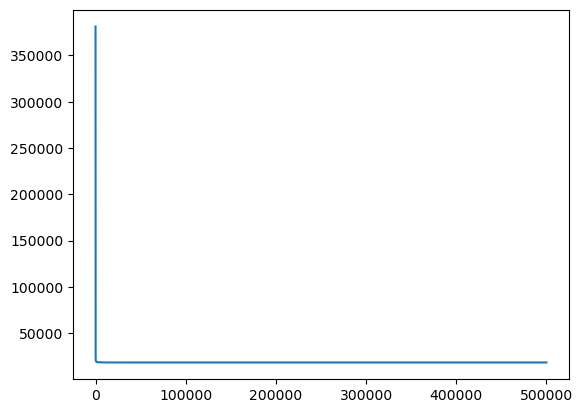

In [90]:
def RMSE(prediction,actual):
    MSE=np.mean((prediction-actual)**2)
    RMSE=np.sqrt(MSE)
    return RMSE

testData=pd.read_csv('testdata.csv')
testData['gender']=testData['gender'].map({'M':1, 'I':0, 'F':-1})
testArray=np.array(testData.drop('Rings',axis=1))
testRings=np.array(testData['Rings'])
normalisedArray=np.column_stack((np.ones(np.shape(testArray)[0]),(testArray-mu)/sigma))

exactPrediction=normalisedArray@LSExact
gdPrediction=normalisedArray@LSGD
ridgePrediction=normalisedArray@Ridge
exactRMSE=RMSE(exactPrediction,testRings)
GDRMSE=RMSE(gdPrediction,testRings)
RidgeRMSE=RMSE(ridgePrediction,testRings)
trainingRMSEexact=RMSE(X@LSExact,rings)
trainingRMSEgd=RMSE(X@LSGD,rings)
trainingRMSEridge=RMSE(X@Ridge,rings)
print(exactRMSE,trainingRMSEexact, "\n", GDRMSE,trainingRMSEgd, "\n",RidgeRMSE,trainingRMSEridge)
print(LSExact,"\n",LSGD,"\n",Ridge)
plt.plot(range(500000),trainingRSS)


In [ ]:
#Bootstrapping to see variance of coefficients in Ridge Regression and Least Squares

def Bootstrap(X,y,iterations):
    samples=np.shape(X)[0]
    Y=np.column_stack((np.ones(samples),X))
    coefmat1=np.zeros((iterations,np.shape(Y)[1]))
    coefmat2=np.zeros((iterations,np.shape(Y)[1]))
    for i in range(iterations):
        rowchoices=np.random.choice(samples,samples,replace=True)
        coefmat1[i]=LinRegExact(Y[rowchoices],y[rowchoices])
        coefmat2[i]=RidgeReg(X[rowchoices],y[rowchoices])
    var1=np.var(coefmat1,axis=0)
    var2=np.var(coefmat2,axis=0)
    mean1=np.mean(coefmat1,axis=0)
    mean2=np.mean(coefmat2,axis=0)
    return var1, var2

print(Bootstrap(data,rings,1000))

(array([0.00147337, 0.00161357, 0.06919104, 0.07969426, 0.08107058,
       0.43825347, 0.11558479, 0.04678765, 0.08523079]), array([0.00151632, 0.00160693, 0.01879237, 0.0235654 , 0.08181323,
       0.03246972, 0.01895001, 0.01677981, 0.02604204]))


In [ ]:
#CV to observe mean RMSE between Ridge Regression and Least Squares

OLSMeanRMSE=cross_validation(X,rings,20,'OLS')[0]
RidgeMeanRMSE=cross_validation(data,rings,20,'Ridge')[0]
print(OLSMeanRMSE,RidgeMeanRMSE)

2.277252430445116 2.277784331209019
